In [ ]:
""" 
Full ML lifecycle Project 
EDA
Feature Engineering
Training
Evaluation
Documentation on GitHub

"""

# predict the final price of each home [SalePrice variable]

In [4]:
# libraries

# Standard import for math ops and dataframe ops
import numpy as np
import pandas as pd

# Visualisations
import seaborn as sns
from matplotlib import pyplot as plt

# Model Building
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor 
from sklearn.linear_model import LinearRegression 

# Homogenous Ensemble Methods
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
# Heterogenous Ensemble Methods
from sklearn.ensemble import VotingRegressor, StackingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_log_error

""" Warnings Filter
import warnings
warnings.filterwarnings('ignore') """

In [19]:
# importing and data assessing

df = pd.read_csv(r"train.csv")

print(f" First 10 rows of the data: \n{df.head(10)}")

print(f"\n Summary Stats: \n{df.describe().T}")

print(f"\n Info: \n{df.info()}")

print(f"\n Missing Values Check: \n{df.isnull().sum().sort_values( ascending = False)}")

print(f"\n {df.shape}")

 First 10 rows of the data: 
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1     

In [29]:
# Correlation Matrix - preprocessing step

corr_matrix = df.corr(numeric_only = True)

# tagret variable:: Sale Price
corr_target = corr_matrix["SalePrice"].sort_values(ascending=False)

print(corr_target.head(28)) # columns with positive coefficients

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
BsmtUnfSF       0.214479
BedroomAbvGr    0.168213
ScreenPorch     0.111447
PoolArea        0.092404
MoSold          0.046432
3SsnPorch       0.044584
Name: SalePrice, dtype: float64


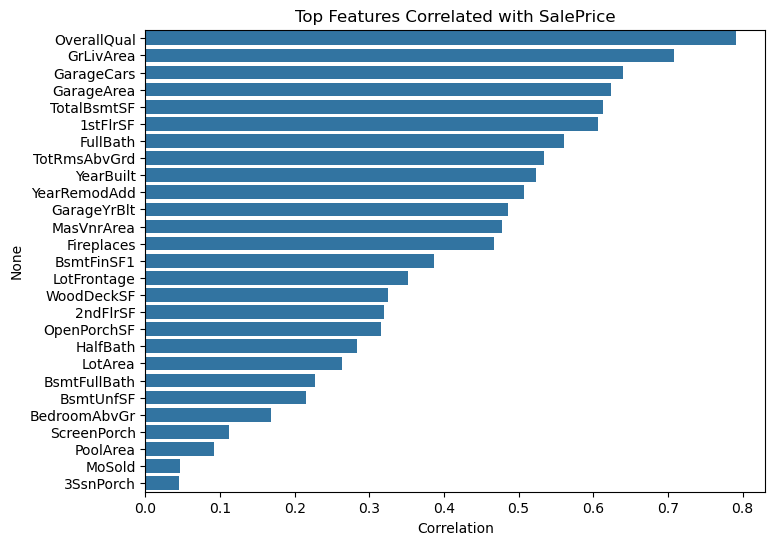

In [31]:
# Visualise Correlation Matrix

top_corr = corr_target[1:28]  # exclude SalePrice itself

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.show()

In [47]:
# Data Preparation for Basic Decision Tree Regressor Model 

# Drop ID (not useful)
df.drop(columns=["Id"], inplace = True)

# 1. Categorical where missing = absence (the house does not have)
cols_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"
]

df[cols_none] = df[cols_none].fillna("None")

# 2. Numerical missing
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median()) # mean is highly affected by large numbers so median is better option
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0) # 0 for missing garage
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

# 3. Small categorical missing
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0]) 
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [48]:
# Seperating Features

train_X = df.drop(columns = "SalePrice")
train_y = df["SalePrice"]

num_cols = train_X.select_dtypes(exclude = "object").columns
cat_cols = train_X.select_dtypes(include = "object").columns

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")

Categorical columns: 43
Numerical columns: 36


In [44]:
# Preprocessing: Scaling Numerical Values and OHE Categorical Columns
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
    ]
)


In [103]:
# Baseline Simple Model: Decision Tree Regressor

X_train, X_val, y_train, y_val = train_test_split(train_X, train_y, test_size = 0.2, random_state = 42)

from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

# Model Evaluation

y_pred = dt_pipeline.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
msle = mean_squared_log_error(y_val, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Squared Log Error: {msle:.4f}")

min_val = df["SalePrice"].min()
max_val = df["SalePrice"].max()
print(f"\nScale of Sale Price. \nMin Sale Price: {min_val}\nMax Sale Price: {max_val}")

print(f"\nError as Percentage of Mean Price:") # to determine if the Decision Tree Model is giving a wide or narrow percentage error spectrum.
mean_price = df["SalePrice"].mean()
mae_pct = mae / mean_price
print(f"MAE as % of mean price: {mae_pct:.2%}")




MSE: 1914437527.6610
MAE: 28288.4486
R2: 0.7504
Root Mean Squared Error: 43754.2858
Mean Squared Log Error: 0.0485

Scale of Sale Price. 
Min Sale Price: 34900
Max Sale Price: 755000

Error as Percentage of Mean Price:
MAE as % of mean price: 15.64%


Overall Model MAPE: 16.16%


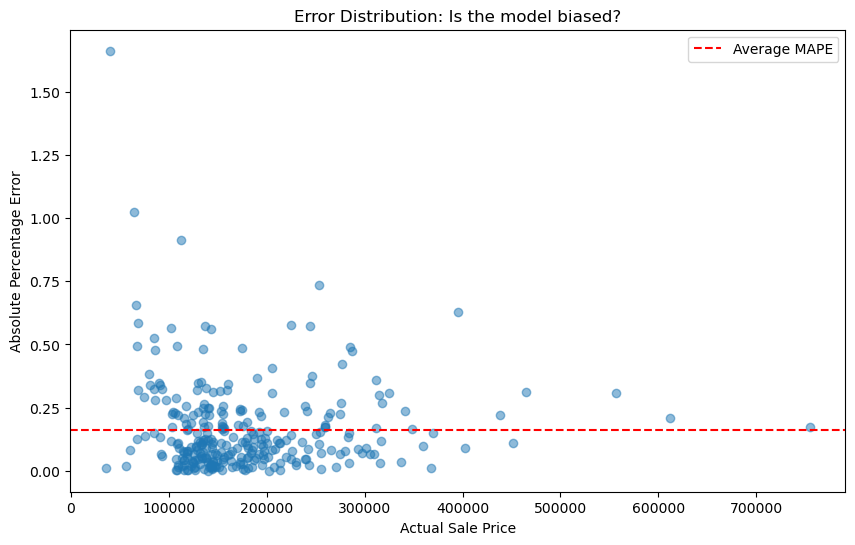

In [109]:
# Calculating and Visualising Model Bias 

# Calculate the percentage error for every single house in your validation set
abs_pct_errors = np.abs((y_val - y_pred) / y_val)

# The overall average MAPE
total_mape = abs_pct_errors.mean()

print(f"Overall Model MAPE: {total_mape:.2%}")

plt.figure(figsize=(10, 6))
plt.scatter(y_val, abs_pct_errors, alpha=0.5)
plt.axhline(y=total_mape, color='r', linestyle='--', label='Average MAPE')
plt.xlabel("Actual Sale Price")
plt.ylabel("Absolute Percentage Error")
plt.title("Error Distribution: Is the model biased?")
plt.legend()
plt.show()


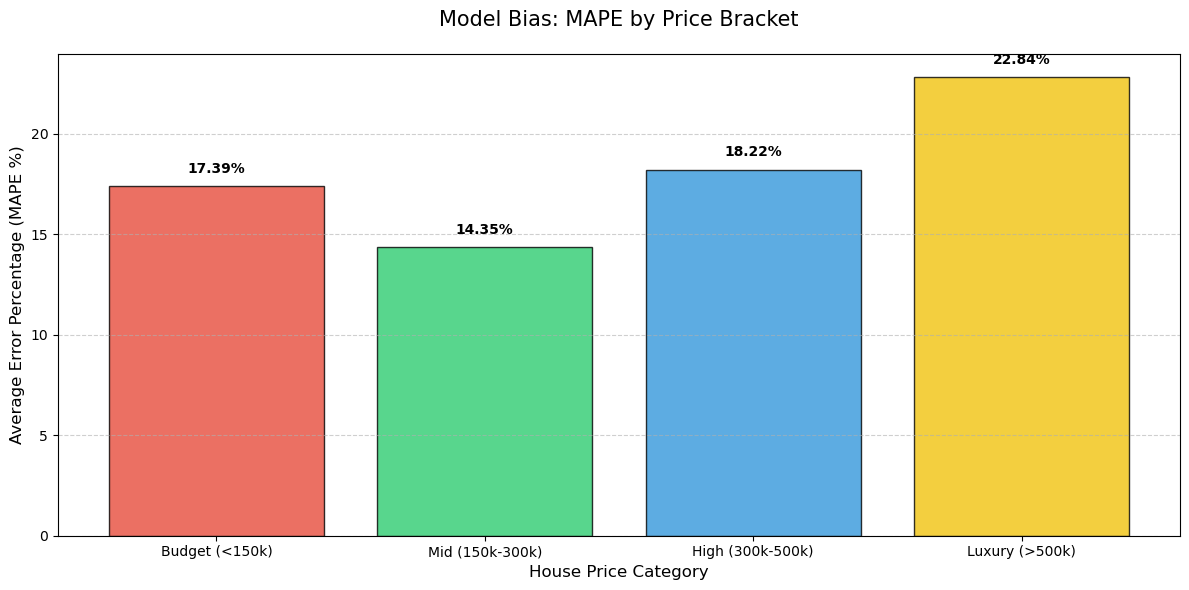

--- MAPE by Price Bracket ---
Price_Bracket
Budget (<150k)      17.389382
Mid (150k-300k)     14.347276
High (300k-500k)    18.223843
Luxury (>500k)      22.842943
Name: APE, dtype: float64


In [112]:
# Bias Investigation with the help of Gemini AI

# 1. Create a results DataFrame
results_df = pd.DataFrame({
    'Actual': y_val, 
    'Predicted': y_pred
})

# 2. Calculate Absolute Percentage Error (APE)
results_df['APE'] = np.abs((results_df['Actual'] - results_df['Predicted']) / results_df['Actual'])

# 3. Define the Price Bins (Ames housing usually ranges from $34k to $755k)
bins = [0, 150000, 300000, 500000, np.inf]
labels = ['Budget (<150k)', 'Mid (150k-300k)', 'High (300k-500k)', 'Luxury (>500k)']
results_df['Price_Bracket'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

# 4. Group by bracket and calculate the Mean APE (MAPE)
# Observed=True handles the Categorical grouping correctly
bin_analysis = results_df.groupby('Price_Bracket', observed=True)['APE'].mean() * 100

# 5. Create the Visual
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f'] # Red, Green, Blue, Yellow
bars = plt.bar(bin_analysis.index, bin_analysis.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Model Bias: MAPE by Price Bracket', fontsize=15, pad=20)
plt.ylabel('Average Error Percentage (MAPE %)', fontsize=12)
plt.xlabel('House Price Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Print the raw numbers for your records
print("--- MAPE by Price Bracket ---")
print(bin_analysis)



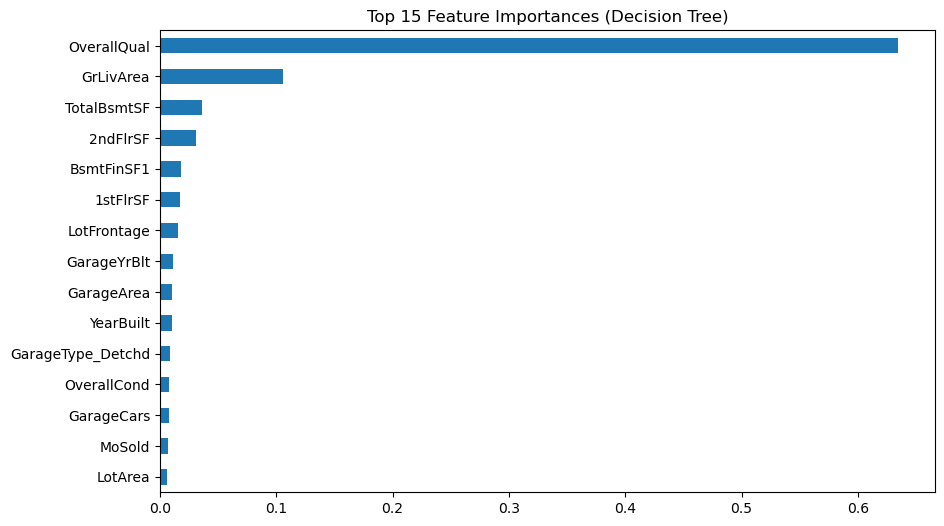

In [59]:
# Feature Importance of Basic Decision Tree Regression Model

# Get feature names
ohe = dt_pipeline.named_steps["preprocessor"].named_transformers_["cat"]

encoded_cat_features = ohe.get_feature_names_out(cat_cols)

all_features = list(num_cols) + list(encoded_cat_features)

# Get Importances
importances = dt_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

#Visualise Feature Importances
plt.figure(figsize=(10,6))
feat_imp.head(15
             ).plot(kind="barh")
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()

In [115]:
"""
Now I am going to use heterogenous and homogenous ensemble methods to compare model perfomances. I will also evaluate the ensemble methods I use to determine model precision
"""

'\nNow I am going to use heterogenous and homogenous ensemble methods to compare model perfomances. I will also evaluate the ensemble methods I use to determine model precision\n'

In [123]:
# Homogenous Ensemble Method: Bagging using RandomForestRegressor()

rf_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(     
        n_estimators = 200, 
        max_depth = None, 
        random_state = 42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_y_pred = rf_pipeline.predict(X_val)

# model evaluation 

rf_mse = mean_squared_error(y_val, rf_y_pred)
rf_mae = mean_absolute_error(y_val, rf_y_pred)
rf_r2 = r2_score(y_val, rf_y_pred)
rf_rmse = root_mean_squared_error(y_val, rf_y_pred)
rf_msle = mean_squared_log_error(y_val, rf_y_pred)

print(f"RF_MSE: {rf_mse:.4f}")
print(f"RF_MAE: {rf_mae:.4f}")
print(f"RF_R2: {rf_r2:.4f}")
print(f"RF_Root Mean Squared Error: {rf_rmse:.4f}")
print(f"RF_Mean Squared Log Error: {rf_msle:.4f}")

min_val = df["SalePrice"].min()
max_val = df["SalePrice"].max()
print(f"\nScale of Sale Price. \nMin Sale Price: {min_val}\nMax Sale Price: {max_val}")

print(f"\nError as Percentage of Mean Price:") # 
mean_price = df["SalePrice"].mean()
rf_mae_pct = rf_mae / mean_price
print(f"RF_MAE as % of mean price: {rf_mae_pct:.2%}")


RF_MSE: 836661385.9616
RF_MAE: 17640.0209
RF_R2: 0.8909
RF_Root Mean Squared Error: 28925.0996
RF_Mean Squared Log Error: 0.0236

Scale of Sale Price. 
Min Sale Price: 34900
Max Sale Price: 755000

Error as Percentage of Mean Price:
RF_MAE as % of mean price: 9.75%


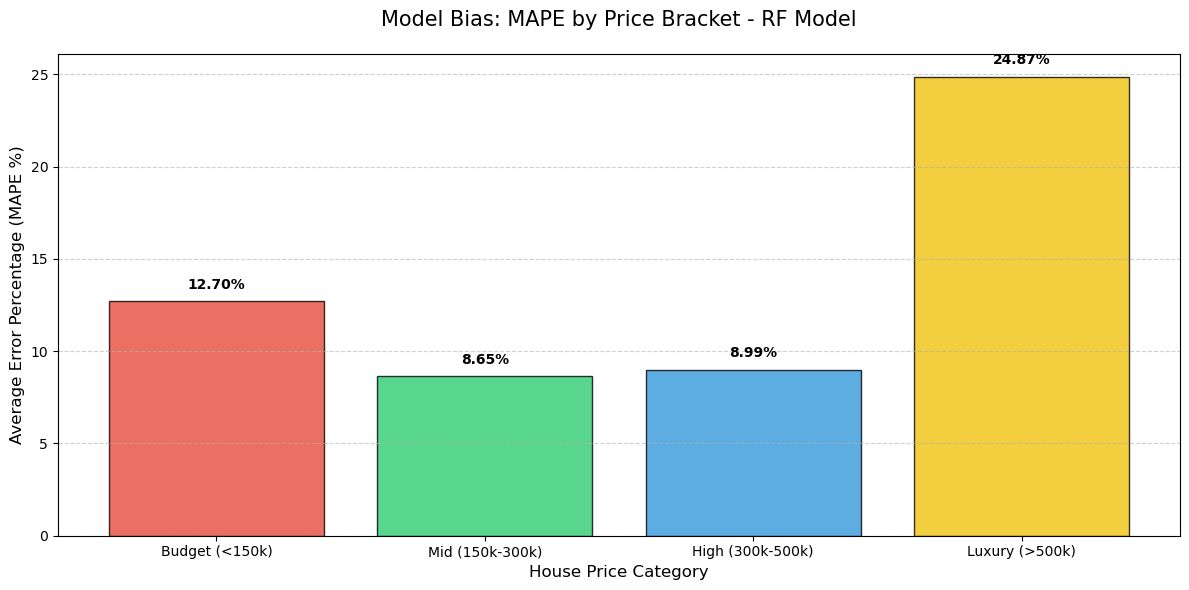

--- MAPE by Price Bracket ---
Price_Bracket
Budget (<150k)      12.696505
Mid (150k-300k)      8.646971
High (300k-500k)     8.994400
Luxury (>500k)      24.867636
Name: APE, dtype: float64


In [125]:
# Bias Investigation with the help of Gemini AI

# 1. Create a results DataFrame
rf_results_df = pd.DataFrame({
    'Actual': y_val, 
    'Predicted': rf_y_pred
})

# 2. Calculate Absolute Percentage Error (APE)
rf_results_df['APE'] = np.abs((rf_results_df['Actual'] - rf_results_df['Predicted']) / rf_results_df['Actual'])

# 3. Define the Price Bins (Ames housing usually ranges from $34k to $755k)
bins = [0, 150000, 300000, 500000, np.inf]
labels = ['Budget (<150k)', 'Mid (150k-300k)', 'High (300k-500k)', 'Luxury (>500k)']
rf_results_df['Price_Bracket'] = pd.cut(rf_results_df['Actual'], bins=bins, labels=labels)

# 4. Group by bracket and calculate the Mean APE (MAPE)
# Observed=True handles the Categorical grouping correctly
bin_analysis = rf_results_df.groupby('Price_Bracket', observed=True)['APE'].mean() * 100

# 5. Create the Visual
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f'] # Red, Green, Blue, Yellow
bars = plt.bar(bin_analysis.index, bin_analysis.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Model Bias: MAPE by Price Bracket - RF Model', fontsize=15, pad=20)
plt.ylabel('Average Error Percentage (MAPE %)', fontsize=12)
plt.xlabel('House Price Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Print the raw numbers for your records
print("--- MAPE by Price Bracket ---")
print(bin_analysis)


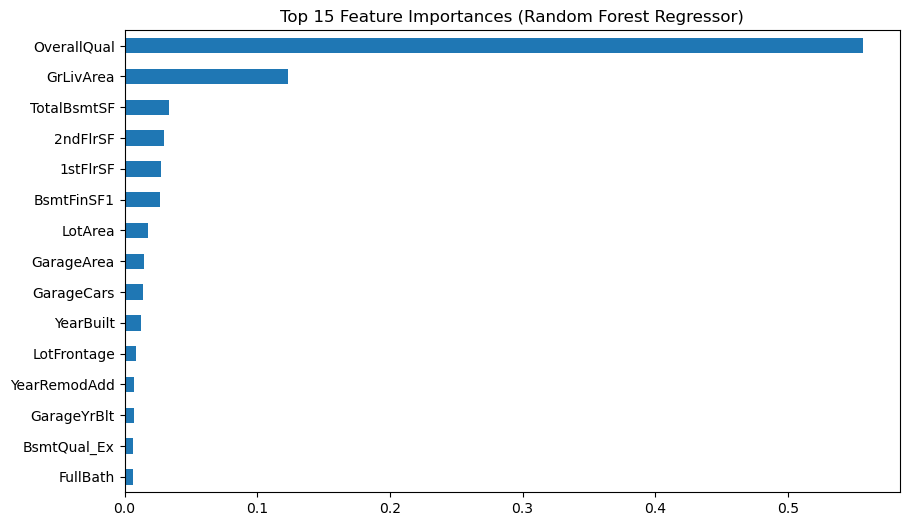

In [126]:
# Feature Importance of Basic Decision Tree Regression Model

# Get feature names
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]

encoded_cat_features = ohe.get_feature_names_out(cat_cols)

all_features = list(num_cols) + list(encoded_cat_features)

# Get Importances
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

#Visualise Feature Importances
plt.figure(figsize=(10,6))
feat_imp.head(15
             ).plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest Regressor)")
plt.gca().invert_yaxis()
plt.show()

In [131]:
# Homogenous Ensemble Method: Boosting using Gradient Boosting Regressor

gb_pipeline = Pipeline ( steps = [
    ("preprocessor", preprocessor), 
    ("model", GradientBoostingRegressor(
        n_estimators = 200, 
        learning_rate = 0.05,
        max_depth = 2, 
        random_state = 42
        
    ))   
])

gb_pipeline.fit(X_train, y_train)

gb_y_pred = gb_pipeline.predict(X_val)

# model evaluation 

gb_mse = mean_squared_error(y_val, gb_y_pred)
gb_mae = mean_absolute_error(y_val, gb_y_pred)
gb_r2 = r2_score(y_val, gb_y_pred)
gb_rmse = root_mean_squared_error(y_val, gb_y_pred)
gb_msle = mean_squared_log_error(y_val, gb_y_pred)

print(f"GB_MSE: {gb_mse:.4f}")
print(f"GB_MAE: {gb_mae:.4f}")
print(f"GB_R2: {gb_r2:.4f}")
print(f"GB_Root Mean Squared Error: {gb_rmse:.4f}")
print(f"GB_Mean Squared Log Error: {gb_msle:.4f}")

min_val = df["SalePrice"].min()
max_val = df["SalePrice"].max()
print(f"\nScale of Sale Price. \nMin Sale Price: {min_val}\nMax Sale Price: {max_val}")

print(f"\nError as Percentage of Mean Price:") # 
mean_price = df["SalePrice"].mean()
gb_mae_pct = gb_mae / mean_price
print(f"GB_MAE as % of mean price: {gb_mae_pct:.2%}")

GB_MSE: 858203582.0141
GB_MAE: 18657.6515
GB_R2: 0.8881
GB_Root Mean Squared Error: 29295.1119
GB_Mean Squared Log Error: 0.0224

Scale of Sale Price. 
Min Sale Price: 34900
Max Sale Price: 755000

Error as Percentage of Mean Price:
GB_MAE as % of mean price: 10.31%


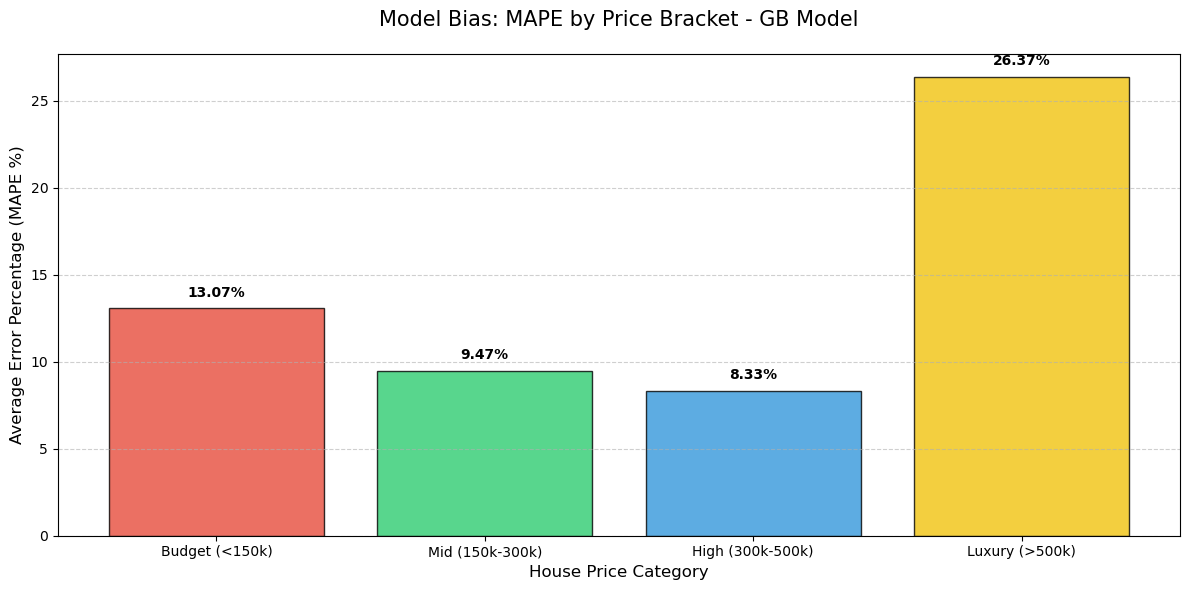

--- MAPE by Price Bracket ---
Price_Bracket
Budget (<150k)      13.069638
Mid (150k-300k)      9.466690
High (300k-500k)     8.328267
Luxury (>500k)      26.374473
Name: APE, dtype: float64


In [132]:
# Bias Investigation with the help of Gemini AI

# 1. Create a results DataFrame
gb_results_df = pd.DataFrame({
    'Actual': y_val, 
    'Predicted': gb_y_pred
})

# 2. Calculate Absolute Percentage Error (APE)
gb_results_df['APE'] = np.abs((gb_results_df['Actual'] - gb_results_df['Predicted']) / gb_results_df['Actual'])

# 3. Define the Price Bins (Ames housing usually ranges from $34k to $755k)
bins = [0, 150000, 300000, 500000, np.inf]
labels = ['Budget (<150k)', 'Mid (150k-300k)', 'High (300k-500k)', 'Luxury (>500k)']
gb_results_df['Price_Bracket'] = pd.cut(gb_results_df['Actual'], bins=bins, labels=labels)

# 4. Group by bracket and calculate the Mean APE (MAPE)
# Observed=True handles the Categorical grouping correctly
bin_analysis = gb_results_df.groupby('Price_Bracket', observed=True)['APE'].mean() * 100

# 5. Create the Visual
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f'] # Red, Green, Blue, Yellow
bars = plt.bar(bin_analysis.index, bin_analysis.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Model Bias: MAPE by Price Bracket - GB Model', fontsize=15, pad=20)
plt.ylabel('Average Error Percentage (MAPE %)', fontsize=12)
plt.xlabel('House Price Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Print the raw numbers for your records
print("--- MAPE by Price Bracket ---")
print(bin_analysis)

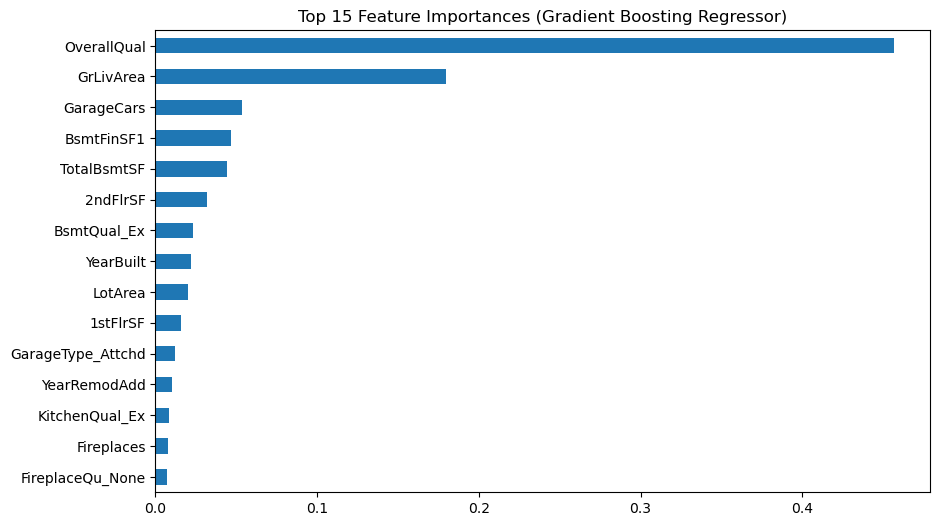

In [133]:
# Feature Importance of Basic Decision Tree Regression Model

# Get feature names
ohe = gb_pipeline.named_steps["preprocessor"].named_transformers_["cat"]

encoded_cat_features = ohe.get_feature_names_out(cat_cols)

all_features = list(num_cols) + list(encoded_cat_features)

# Get Importances
importances = gb_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

#Visualise Feature Importances
plt.figure(figsize=(10,6))
feat_imp.head(15
             ).plot(kind="barh")
plt.title("Top 15 Feature Importances (Gradient Boosting Regressor)")
plt.gca().invert_yaxis()
plt.show()

In [134]:
# Heterogenous Ensemble Models: Voting Regressor

vr_model = VotingRegressor([
    ("rf", rf_pipeline), 
    ("gb", gb_pipeline)
    
])

vr_model.fit(X_train, y_train)

vr_y_pred = vr_model.predict(X_val)

# model evaluation 

vr_mse = mean_squared_error(y_val, vr_y_pred)
vr_mae = mean_absolute_error(y_val, vr_y_pred)
vr_r2 = r2_score(y_val, vr_y_pred)
vr_rmse = root_mean_squared_error(y_val, vr_y_pred)
vr_msle = mean_squared_log_error(y_val, vr_y_pred)

print(f"VR_MSE: {vr_mse:.4f}")
print(f"VR_MAE: {vr_mae:.4f}")
print(f"VR_R2: {vr_r2:.4f}")
print(f"VR_Root Mean Squared Error: {vr_rmse:.4f}")
print(f"VR_Mean Squared Log Error: {vr_msle:.4f}")

min_val = df["SalePrice"].min()
max_val = df["SalePrice"].max()
print(f"\nScale of Sale Price. \nMin Sale Price: {min_val}\nMax Sale Price: {max_val}")

print(f"\nError as Percentage of Mean Price:") # 
mean_price = df["SalePrice"].mean()
vr_mae_pct = vr_mae / mean_price
print(f"VR_MAE as % of mean price: {vr_mae_pct:.2%}")

VR_MSE: 804796407.8181
VR_MAE: 17454.9174
VR_R2: 0.8951
VR_Root Mean Squared Error: 28368.9339
VR_Mean Squared Log Error: 0.0218

Scale of Sale Price. 
Min Sale Price: 34900
Max Sale Price: 755000

Error as Percentage of Mean Price:
VR_MAE as % of mean price: 9.65%


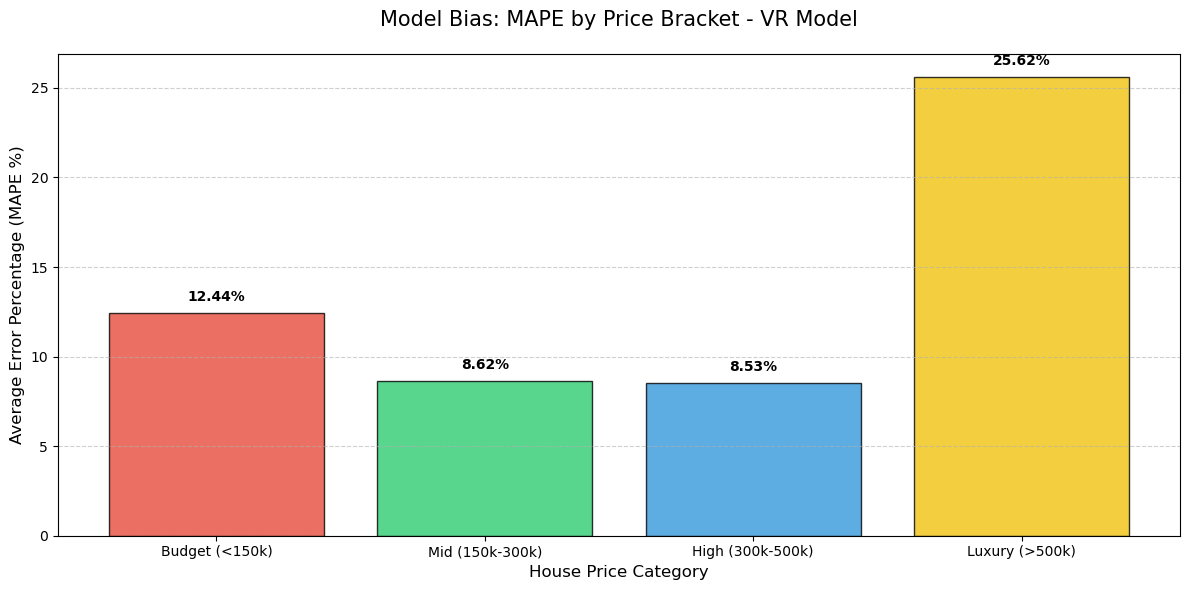

--- MAPE by Price Bracket ---
Price_Bracket
Budget (<150k)      12.435333
Mid (150k-300k)      8.622201
High (300k-500k)     8.528648
Luxury (>500k)      25.621055
Name: APE, dtype: float64


In [135]:
# Bias Investigation with the help of Gemini AI

# 1. Create a results DataFrame
vr_results_df = pd.DataFrame({
    'Actual': y_val, 
    'Predicted': vr_y_pred
})

# 2. Calculate Absolute Percentage Error (APE)
vr_results_df['APE'] = np.abs((vr_results_df['Actual'] - vr_results_df['Predicted']) / vr_results_df['Actual'])

# 3. Define the Price Bins (Ames housing usually ranges from $34k to $755k)
bins = [0, 150000, 300000, 500000, np.inf]
labels = ['Budget (<150k)', 'Mid (150k-300k)', 'High (300k-500k)', 'Luxury (>500k)']
vr_results_df['Price_Bracket'] = pd.cut(vr_results_df['Actual'], bins=bins, labels=labels)

# 4. Group by bracket and calculate the Mean APE (MAPE)
# Observed=True handles the Categorical grouping correctly
bin_analysis = vr_results_df.groupby('Price_Bracket', observed=True)['APE'].mean() * 100

# 5. Create the Visual
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f'] # Red, Green, Blue, Yellow
bars = plt.bar(bin_analysis.index, bin_analysis.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Model Bias: MAPE by Price Bracket - VR Model', fontsize=15, pad=20)
plt.ylabel('Average Error Percentage (MAPE %)', fontsize=12)
plt.xlabel('House Price Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Print the raw numbers for your records
print("--- MAPE by Price Bracket ---")
print(bin_analysis)

In [141]:
# Feature Importance of Voting Regression Model by Gemini AI



In [144]:
# Heterogenous Ensemble Method: Stacking Regressor 

sr_model = StackingRegressor(
    estimators=[
        ("rf", rf_pipeline),
        ("gb", gb_pipeline)
    ],
    final_estimator = LinearRegression()
)

sr_model.fit(X_train, y_train)

sr_y_pred = sr_model.predict(X_val)

# model evaluation 

sr_mse = mean_squared_error(y_val, sr_y_pred)
sr_mae = mean_absolute_error(y_val, sr_y_pred)
sr_r2 = r2_score(y_val, sr_y_pred)
sr_rmse = root_mean_squared_error(y_val, sr_y_pred)
sr_msle = mean_squared_log_error(y_val, sr_y_pred)

print(f"SR_MSE: {sr_mse:.4f}")
print(f"SR_MAE: {sr_mae:.4f}")
print(f"SR_R2: {sr_r2:.4f}")
print(f"SR_Root Mean Squared Error: {sr_rmse:.4f}")
print(f"SR_Mean Squared Log Error: {sr_msle:.4f}")

min_val = df["SalePrice"].min()
max_val = df["SalePrice"].max()
print(f"\nScale of Sale Price. \nMin Sale Price: {min_val}\nMax Sale Price: {max_val}")

print(f"\nError as Percentage of Mean Price:") # 
mean_price = df["SalePrice"].mean()
sr_mae_pct = sr_mae / mean_price
print(f"SR_MAE as % of mean price: {sr_mae_pct:.2%}")

SR_MSE: 778544569.1264
SR_MAE: 17678.5748
SR_R2: 0.8985
SR_Root Mean Squared Error: 27902.4115
SR_Mean Squared Log Error: 0.0206

Scale of Sale Price. 
Min Sale Price: 34900
Max Sale Price: 755000

Error as Percentage of Mean Price:
SR_MAE as % of mean price: 9.77%


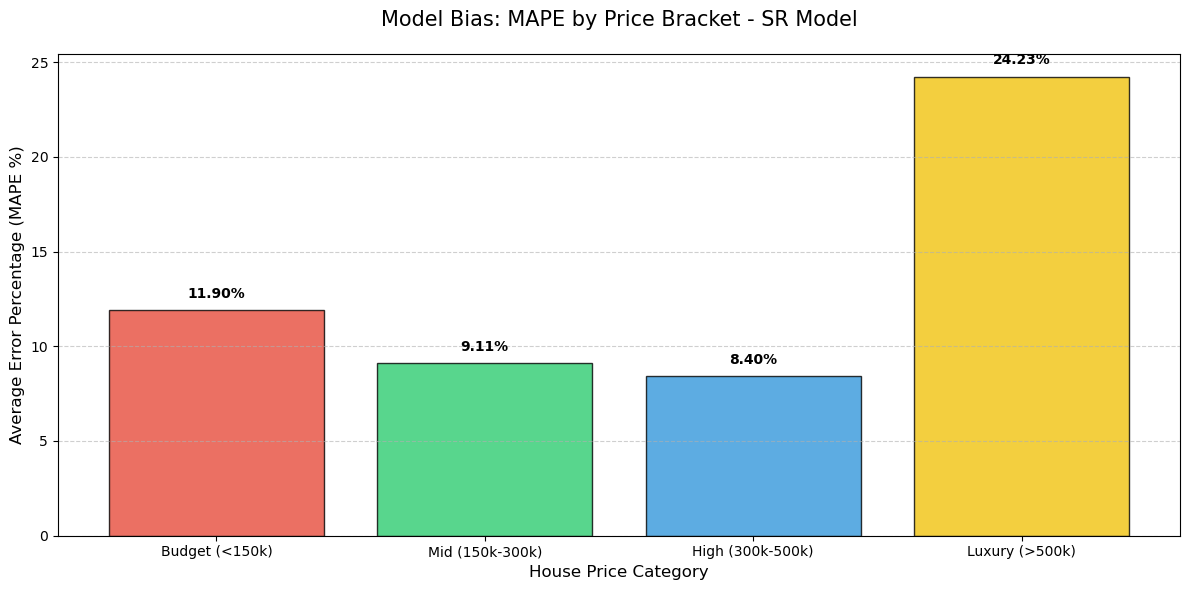

--- MAPE by Price Bracket ---
Price_Bracket
Budget (<150k)      11.896194
Mid (150k-300k)      9.109810
High (300k-500k)     8.404971
Luxury (>500k)      24.226791
Name: APE, dtype: float64


In [165]:
# Bias Investigation with the help of Gemini AI

# 1. Create a results DataFrame
sr_results_df = pd.DataFrame({
    'Actual': y_val, 
    'Predicted': sr_y_pred
})

# 2. Calculate Absolute Percentage Error (APE)
sr_results_df['APE'] = np.abs((sr_results_df['Actual'] - sr_results_df['Predicted']) / sr_results_df['Actual'])

# 3. Define the Price Bins (Ames housing usually ranges from $34k to $755k)
bins = [0, 150000, 300000, 500000, np.inf]
labels = ['Budget (<150k)', 'Mid (150k-300k)', 'High (300k-500k)', 'Luxury (>500k)']
sr_results_df['Price_Bracket'] = pd.cut(sr_results_df['Actual'], bins=bins, labels=labels)

# 4. Group by bracket and calculate the Mean APE (MAPE)
# Observed=True handles the Categorical grouping correctly
bin_analysis = sr_results_df.groupby('Price_Bracket', observed=True)['APE'].mean() * 100

# 5. Create the Visual
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f'] # Red, Green, Blue, Yellow
bars = plt.bar(bin_analysis.index, bin_analysis.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Model Bias: MAPE by Price Bracket - SR Model', fontsize=15, pad=20)
plt.ylabel('Average Error Percentage (MAPE %)', fontsize=12)
plt.xlabel('House Price Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Print the raw numbers for your records
print("--- MAPE by Price Bracket ---")
print(bin_analysis)

In [ ]:
# Feature Importance Graph of Stacking Regressor - by the help of Gemini AI

In [166]:
# Comparing Models

models = {
    "Decision Tree": y_pred, # Your original baseline
    "Random Forest (Bagging)": rf_pipeline.predict(X_val),
    "Grad Boosting (Boosting)": gb_pipeline.predict(X_val),
    "Voting (Ensemble)": vr_model.predict(X_val),
    "Stacking (Ensemble)": sr_model.predict(X_val)
}

leaderboard = []
for name, preds in models.items():
    mae = mean_absolute_error(y_val, preds)
    mape = (np.abs((y_val - preds) / y_val)).mean() * 100
    r2 = r2_score(y_val, preds)
    leaderboard.append({"Model": name, "MAE": mae, "MAPE %": mape, "R2": r2})

print(pd.DataFrame(leaderboard).sort_values(by="R2", ascending=False).to_string(index=False))


                   Model          MAE    MAPE %       R2
     Stacking (Ensemble) 17678.574783 10.540826 0.898499
       Voting (Ensemble) 17454.917418 10.605274 0.895077
 Random Forest (Bagging) 17640.020908 10.766297 0.890922
Grad Boosting (Boosting) 18657.651457 11.273629 0.888114
           Decision Tree 28288.448630 16.161480 0.750410


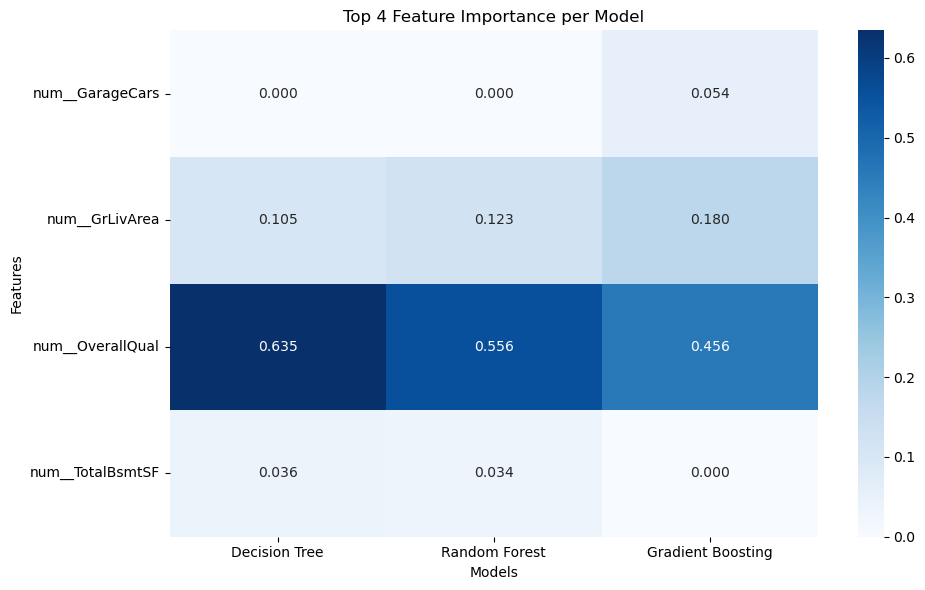

In [155]:
# Feature Table for models used - Gemini AI inspired

# ===== FEATURE IMPORTANCE HEATMAP (FINAL VISUAL) =====

importance_data = {}

for name, pipe in [
    ("Decision Tree", dt_pipeline),
    ("Random Forest", rf_pipeline),
    ("Gradient Boosting", gb_pipeline)
]:
    # Extract feature importance
    importance = pipe.named_steps['model'].feature_importances_
    
    # Get feature names
    feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
    
    # Create series and get top 3
    top_4 = pd.Series(importance, index=feature_names)\
                .sort_values(ascending=False)\
                .head(3)
    
    importance_data[name] = top_4

# Combine into DataFrame
importance_df = pd.DataFrame(importance_data).fillna(0)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(importance_df, annot=True, fmt=".3f", cmap="Blues")

plt.title("Top 4 Feature Importance per Model")
plt.ylabel("Features")
plt.xlabel("Models")

plt.tight_layout()
plt.savefig("feature_importance_heatmap.png")  # Saves for GitHub
plt.show()



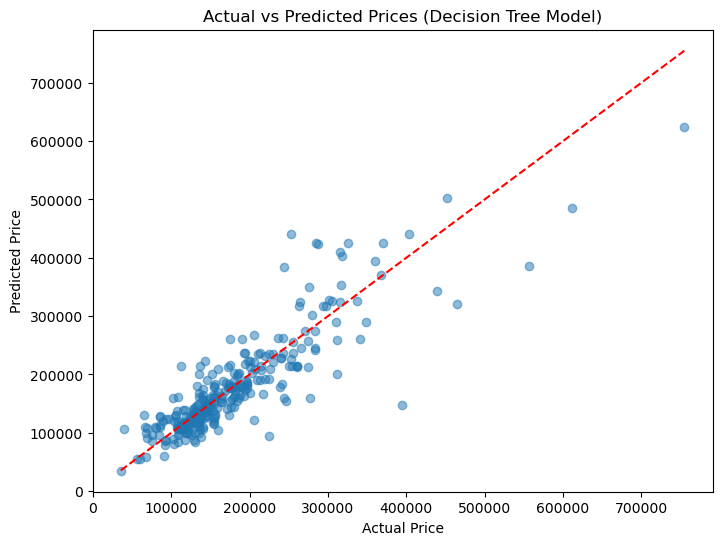

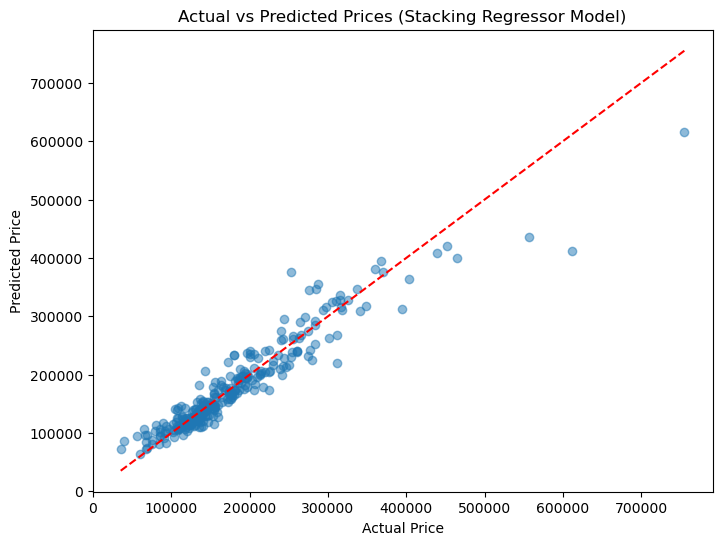

In [168]:
# Actual vs Predicted Scatter Plots: For Base Model [Decision Tree Regressor model] and Best Model [Stacking Regressor model]

# DTR Model
plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Decision Tree Model)")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.show()

# SR Model
plt.figure(figsize=(8,6))
plt.scatter(y_val, sr_y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Stacking Regressor Model)")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.show()

# 

In [169]:
"""Closing Remarks: There is clear improvement from the base model to the best model used and that can be seen by the clusters tucking closer to the line of best of fit which shows that the models predictions are not far off from the actual values and that there is low bias. Could the model be overfitting?"""

'Closing Remarks: There is clear improvement from the base model to the best model used and that can be seen by the clusters tucking closer to the line of best of fit which shows that the models predictions are not far off from the actual values and that there is low bias. Could the model be overfitting?'